In [ ]:
import numpy as np
import matplotlib.pyplot as plt

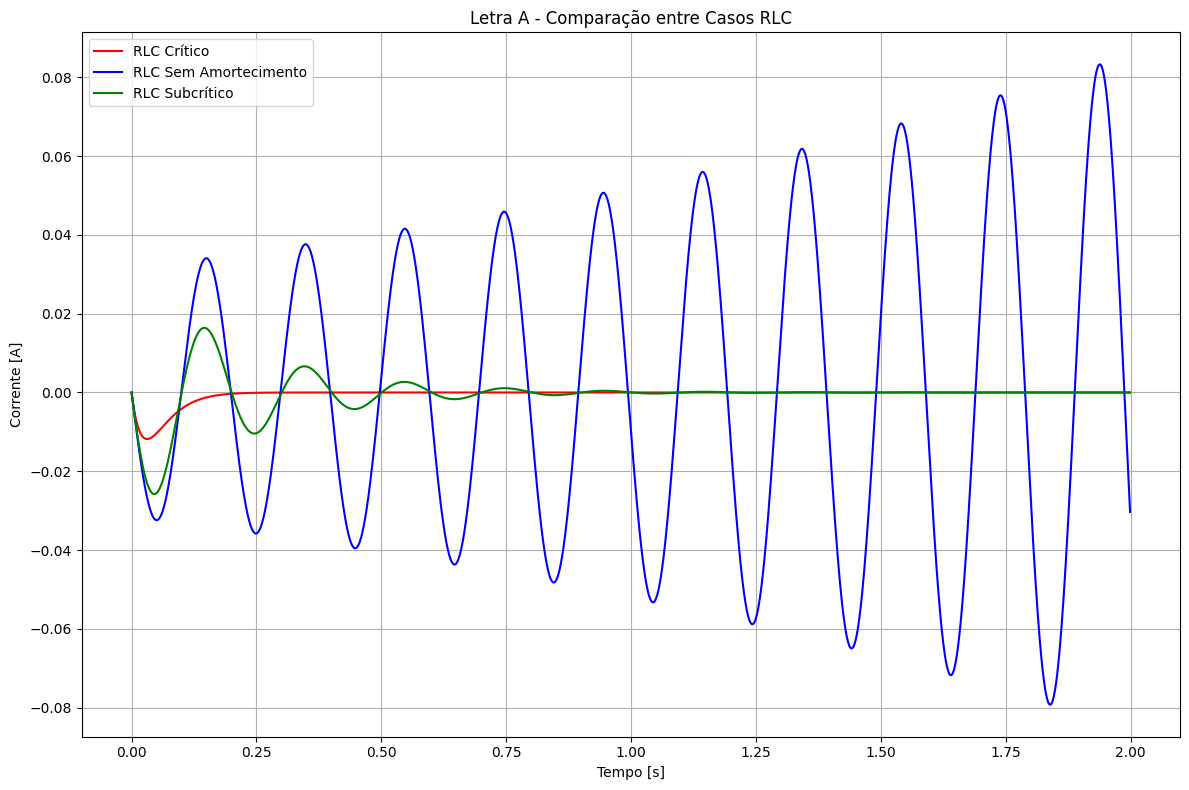

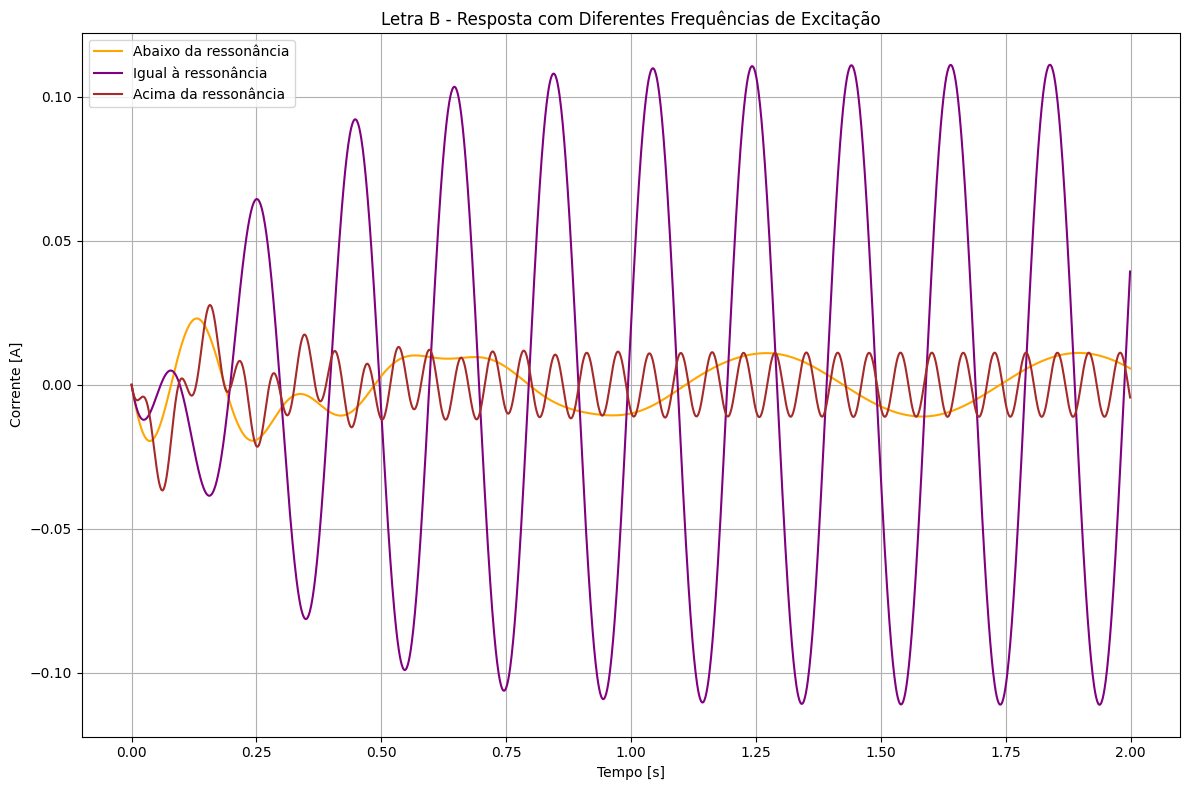

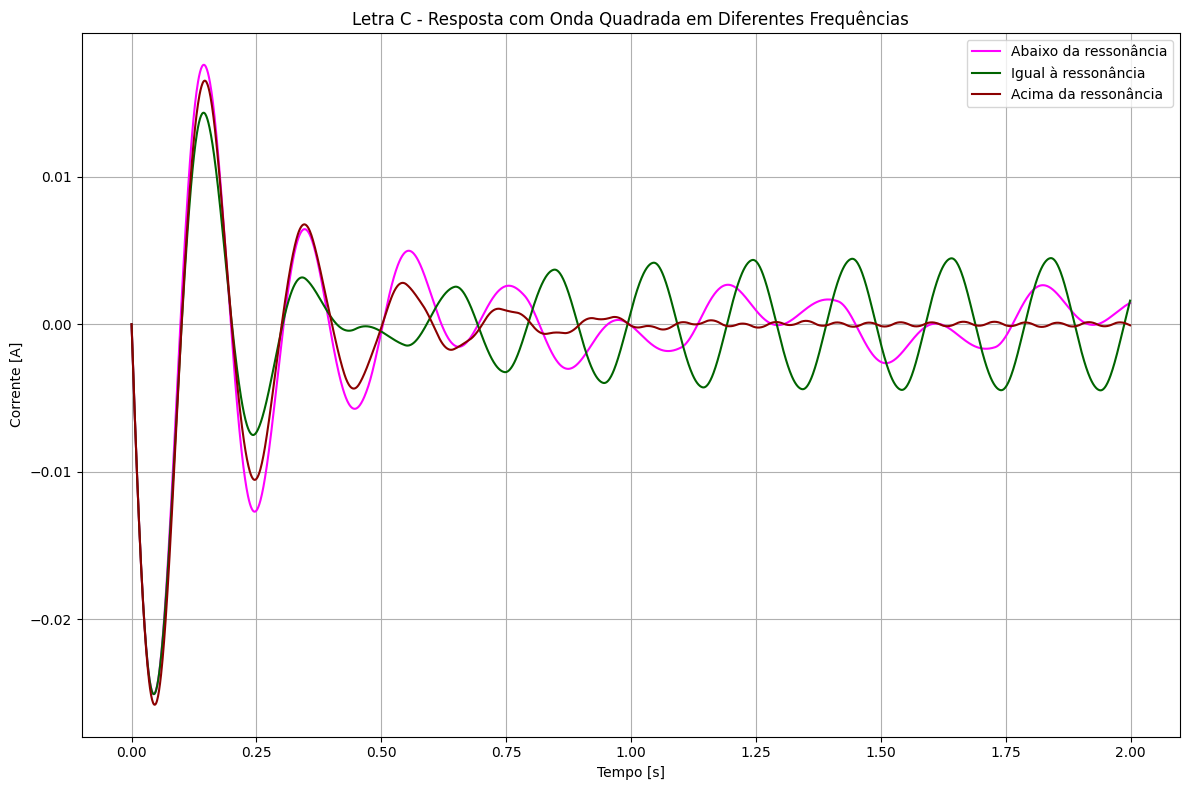

In [ ]:

dt = 1e-3
t_final = 2.0
t = np.arange(0, t_final, dt)
tamanho = len(t)


U0 = 1.0
L = 1.0
C = 1e-3
R_semamortecimento = 0
R_critico = 2.0 * np.sqrt(L/C)
R_subcritico = 10.0

def f(R, L, C, i, didt, omega0, t):
    didt = -(R / L) * didt - (1.0 / (L * C)) * i + ((U0*omega0)/L)*np.cos(omega0*t)
    return didt

############### LETRA A #################3333333333333
plt.figure(figsize=(12, 8))

for nm in range(3):
    i = np.zeros(tamanho)
    didt = np.zeros(tamanho)

    VC0 = 1.0
    i[0] = 0.0
    didt[0] = -VC0/L

    if nm == 0:
        R = R_critico
        titulo = "RLC Crítico"
        cor = 'red'
    elif nm == 1:
        R = R_semamortecimento
        titulo = "RLC Sem Amortecimento"
        cor = 'blue'
    elif nm == 2:
        R = R_subcritico
        titulo = "RLC Subcrítico"
        cor = 'green'

    # Usei o método de Euler para todas as letras A, B e C
    for ij in range(tamanho-1):
        i[ij+1] = i[ij] + didt[ij] * dt
        didt[ij+1] = didt[ij] + f(R, L, C, i[ij], didt[ij], 0, 0) * dt

    plt.plot(t, i, label=titulo, color=cor, linewidth=1.5)

plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.title('Letra A - Comparação entre Casos RLC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##################333## LETRA B #######################
plt.figure(figsize=(12, 8))

omega_valores = [10.0, 31.62, 100.0]
titulos_b = ["Abaixo da ressonância", "Igual à ressonância", "Acima da ressonância"]
cores_b = ['orange', 'purple', 'brown']

for rt in range(3):
    i = np.zeros(tamanho)
    didt = np.zeros(tamanho)

    VC0 = 1.0
    i[0] = 0.0
    didt[0] = -VC0/L
    omega0 = omega_valores[rt]

    for ij in range(tamanho-1):
        i[ij+1] = i[ij] + didt[ij] * dt
        didt[ij+1] = didt[ij] + f(R_subcritico, L, C, i[ij], didt[ij], omega0, t[ij]) * dt

    plt.plot(t, i, label=titulos_b[rt], color=cores_b[rt], linewidth=1.5)

plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.title('Letra B - Resposta com Diferentes Frequências de Excitação')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###################### LETRA C ####################33

def f_quadrada(R, L, C, i, didt, omega0, t):
    ueforca = U0 * np.sign(np.cos(omega0 * t))
    didt = -(R / L) * didt - (1.0 / (L * C)) * i + (ueforca / L)
    return didt

plt.figure(figsize=(12, 8))

omega_quadrada = [10.0, 31.62, 100.0]
titulos_c = ["Abaixo da ressonância", "Igual à ressonância", "Acima da ressonância"]
cores_c = ['magenta', 'darkgreen', 'darkred']

for k in range(3):
    i = np.zeros(tamanho)
    didt = np.zeros(tamanho)

    VC0 = 1.0
    i[0] = 0.0
    didt[0] = -VC0 / L
    omega0 = omega_quadrada[k]

    for ij in range(tamanho - 1):
        i[ij + 1] = i[ij] + didt[ij] * dt
        didt[ij + 1] = didt[ij] + f_quadrada(R_subcritico, L, C, i[ij], didt[ij], omega0, t[ij]) * dt

    plt.plot(t, i, label=titulos_c[k], color=cores_c[k], linewidth=1.5)

plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.title('Letra C - Resposta com Onda Quadrada em Diferentes Frequências')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
